In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df=pd.read_csv(r"C:\Users\Spandan\Downloads\social_media_performance.csv")

In [5]:
print(df.head())

   post_id  platform content_type       topic language region  \
0        1  LinkedIn      article  Technology       UR     BR   
1        2  LinkedIn         poll      Health       FR     JP   
2        3  LinkedIn      article      Travel       HI     FR   
3        4  LinkedIn        image      Sports       DE     DE   
4        5  LinkedIn         poll    Business       DE     US   

         post_datetime                                           hashtags  \
0  2025-04-25 09:47:00  #AI #Innovation #TechTrends #Programming #Codi...   
1  2025-10-29 09:44:00  #Fitness #Nutrition #Wellness #Health #MentalH...   
2  2025-02-10 14:12:00  #Travel #Journey #Adventure #Tourism #ExploreM...   
3  2025-04-18 22:41:00                         #Cricket #Workout #Fitness   
4  2025-04-28 10:17:00             #Entrepreneur #Leadership #StartupLife   

   sentiment_score  views  likes  comments  shares  engagement_rate  is_viral  
0             0.76  37781   1202       462     185           0.049

In [6]:
print(df.tail())

      post_id platform content_type          topic language region  \
9995     9996  YouTube        video           Food       PT     IN   
9996     9997  YouTube        video     Technology       DE     US   
9997     9998  YouTube        video  Entertainment       JA     IN   
9998     9999  YouTube        video         Health       EN     DE   
9999    10000  YouTube        video         Health       UR     CA   

            post_datetime                                           hashtags  \
9995  2025-02-22 19:01:00  #Foodie #Cooking #Food #Recipe #FoodBlog #MustTry   
9996  2025-01-18 20:51:00  #Programming #DataScience #CodingLife #Innovat...   
9997  2025-08-12 20:58:00                             #Funny #Viral #ShowBiz   
9998  2025-04-27 19:04:00  #Wellness #Health #MentalHealth #Fitness #Nutr...   
9999  2025-05-16 12:21:00                   #Nutrition #MentalHealth #Health   

      sentiment_score   views  likes  comments  shares  engagement_rate  \
9995            -0.05  

In [7]:
print(df.shape)

(10000, 15)


In [8]:
print(df.columns)

Index(['post_id', 'platform', 'content_type', 'topic', 'language', 'region',
       'post_datetime', 'hashtags', 'sentiment_score', 'views', 'likes',
       'comments', 'shares', 'engagement_rate', 'is_viral'],
      dtype='object')


In [9]:
print(df.dtypes)

post_id              int64
platform            object
content_type        object
topic               object
language            object
region              object
post_datetime       object
hashtags            object
sentiment_score    float64
views                int64
likes                int64
comments             int64
shares               int64
engagement_rate    float64
is_viral             int64
dtype: object


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          10000 non-null  int64  
 1   platform         10000 non-null  object 
 2   content_type     10000 non-null  object 
 3   topic            10000 non-null  object 
 4   language         10000 non-null  object 
 5   region           10000 non-null  object 
 6   post_datetime    10000 non-null  object 
 7   hashtags         10000 non-null  object 
 8   sentiment_score  10000 non-null  float64
 9   views            10000 non-null  int64  
 10  likes            10000 non-null  int64  
 11  comments         10000 non-null  int64  
 12  shares           10000 non-null  int64  
 13  engagement_rate  10000 non-null  float64
 14  is_viral         10000 non-null  int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 1.1+ MB
None


In [11]:
print(df.describe())

           post_id  sentiment_score          views         likes  \
count  10000.00000     10000.000000   10000.000000   10000.00000   
mean    5000.50000         0.440221  212142.158100   15236.87470   
std     2886.89568         0.452148  254526.880805   20450.03532   
min        1.00000        -1.000000     116.000000       3.00000   
25%     2500.75000         0.160000   30936.500000    1623.00000   
50%     5000.50000         0.560000   78193.000000    5504.00000   
75%     7500.25000         0.780000  343206.750000   21467.25000   
max    10000.00000         1.000000  999022.000000  116255.00000   

           comments        shares  engagement_rate      is_viral  
count  10000.000000  10000.000000     10000.000000  10000.000000  
mean    5860.139600   2343.759700         0.112667      0.545700  
std     7865.396933   3146.163176         0.064301      0.497932  
min        1.000000      0.000000         0.008300      0.000000  
25%      624.000000    249.000000         0.061900  

In [12]:
df.isnull()

,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,sentiment_score,views,likes,comments,shares,engagement_rate,is_viral
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [13]:
df = df.drop(['post_id', 'hashtags', 'post_datetime', 'engagement_rate'], axis=1)

In [14]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 platform           0
content_type       0
topic              0
language           0
region             0
sentiment_score    0
views              0
likes              0
comments           0
shares             0
is_viral           0
dtype: int64


In [15]:
df = pd.get_dummies(df, drop_first=True)

In [16]:
X = df.drop('is_viral', axis=1)
y = df['is_viral']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

In [19]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

In [20]:
y_pred = dt.predict(X_test)

In [21]:
print("\nBasic Decision Tree Performance")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Basic Decision Tree Performance
Test Accuracy: 0.845

Confusion Matrix:
 [[783 119]
 [191 907]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.87      0.83       902
           1       0.88      0.83      0.85      1098

    accuracy                           0.84      2000
   macro avg       0.84      0.85      0.84      2000
weighted avg       0.85      0.84      0.85      2000



In [22]:
cv_scores = cross_val_score(dt, X, y, cv=5)

In [34]:
print("\n 5-Fold Cross Validation")
print("Fold Accuracies:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())



 5-Fold Cross Validation
Fold Accuracies: [0.6575 0.9    0.796  0.799  0.916 ]
Average CV Accuracy: 0.8137000000000001


In [24]:
param_grid = {
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}


In [25]:
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [26]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 6, 8, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [27]:
print("\nBest Parameters After Tuning")
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)



Best Parameters After Tuning
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.9649999999999999


In [29]:
best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test)

print("\nTuned Model Performance")
print("Final Test Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))


Tuned Model Performance
Final Test Accuracy: 0.9725

Confusion Matrix:
 [[ 872   30]
 [  25 1073]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       902
           1       0.97      0.98      0.98      1098

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



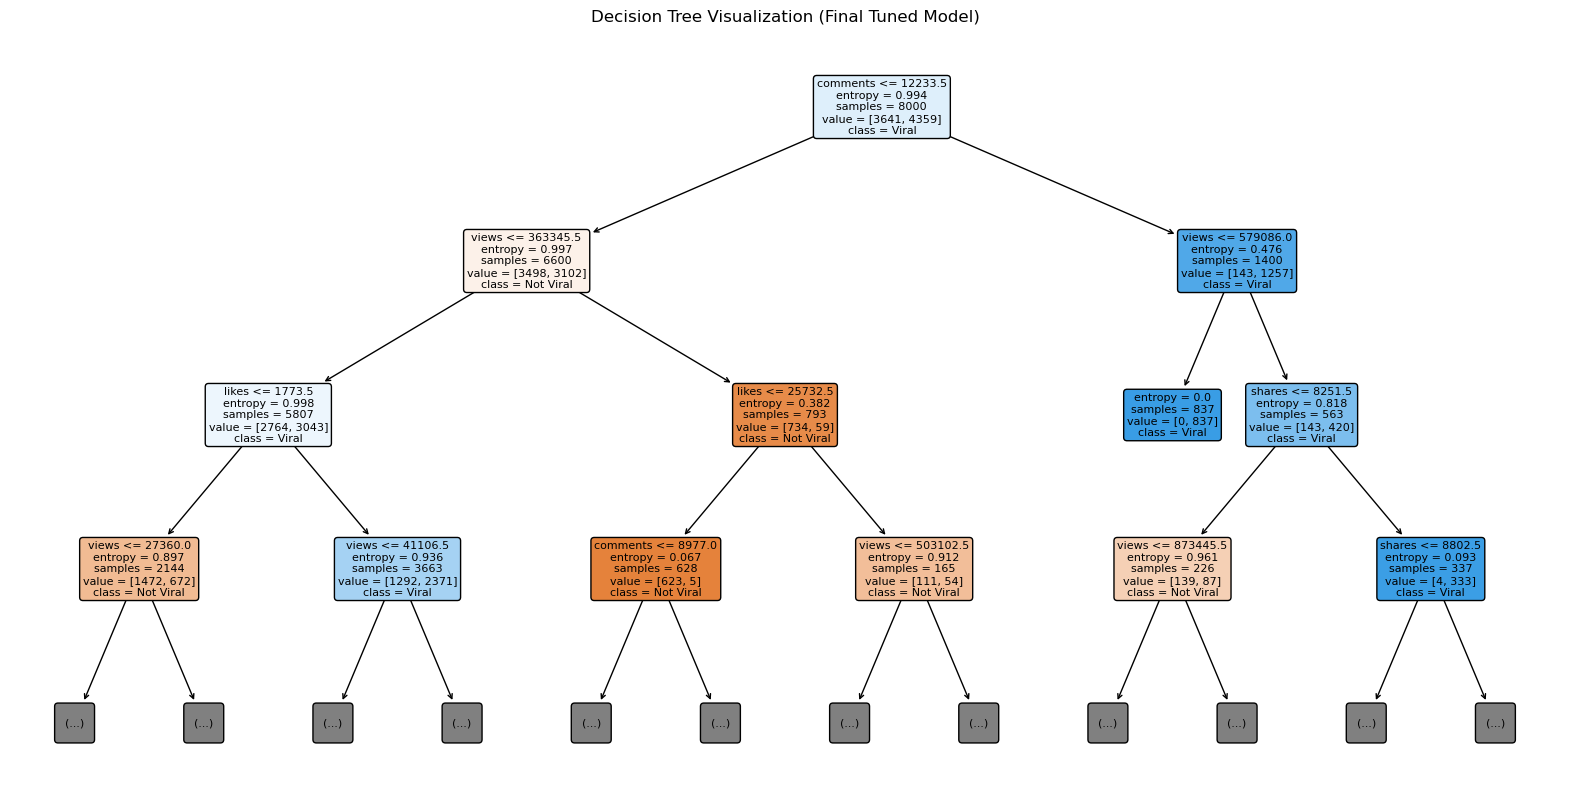

In [33]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    feature_names=list(X.columns),   # convert to list
    class_names=['Not Viral', 'Viral'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization (Final Tuned Model)")
plt.show()